# Laser hold / settle / window study

Coarse (photodiode) scans only. Does **not** replace the lock notebooks. The Koheron diode must already be on (`Laser_Power.ipynb`); this notebook does not turn it on or off.

After **Setup**, each study cell is self-contained: knobs at the top, re-run that cell alone.

1. Park 10 s at -1.0 ... +1.0 V, then the same -0.5 to +0.5 V sweep (no extra sit at -0.5).
2. Same with a 3 s park.
3. Overlapping 0.12 V windows, starts 0.1 V apart, 1 s sit at each window start.
4. Same windows, 10 s sit.
5. Same windows as 3, 1 s sit, 8 s ramp.
6. Same windows as 4, 10 s sit, 8 s ramp.


In [1]:
# ------------------------------------------------------------
# Setup — run once
# ------------------------------------------------------------

import sys
import time
from pathlib import Path

import numpy as np
import matplotlib.pyplot as plt
from matplotlib import cm
from matplotlib.colors import Normalize

ROOT = Path.cwd()
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

from laserlock import LaserDrive, connect, silence_feedback
from laserlock.peaks import analyze_spectrum

HOSTNAME = "rp-f0c970.local"
PYRPL_CONFIG = "my_config"
RELOAD_FPGA = True
IDLE_V = 0.0

p, rp = connect(
    hostname=HOSTNAME,
    config=PYRPL_CONFIG,
    reloadfpga=RELOAD_FPGA,
    gui=False,
)
drive = LaserDrive(rp, idle_v=IDLE_V)
drive.enable_idle()
silence_feedback(rp)


def overlay_pd(traces, color_values, title, xlim, color_label):
    """Overlay PD traces. color_values[i] sets the color of traces[i]."""
    vals = np.asarray(color_values, dtype=float)
    norm = Normalize(vmin=float(np.min(vals)), vmax=float(np.max(vals)))
    cmap = cm.viridis
    fig, ax = plt.subplots(figsize=(11, 5))
    for (x, pd), cval in zip(traces, vals):
        ax.plot(x, pd, color=cmap(norm(cval)), lw=1.2, alpha=0.85)
    sm = cm.ScalarMappable(norm=norm, cmap=cmap)
    sm.set_array([])
    fig.colorbar(sm, ax=ax, label=color_label)
    ax.set_xlim(xlim)
    ax.set_xlabel("Laser modulation voltage (V)")
    ax.set_ylabel("Photodiode (V)")
    ax.set_title(title)
    ax.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()
    return fig, ax


def peak2_voltage(x, pd):
    """Peak-2 voltage if a triplet is found, else NaN."""
    a = analyze_spectrum(x, pd, peak_choice=2, require_triplet=True)
    if not a["ok"] or a.get("target") is None:
        return float("nan")
    return float(a["target"]["voltage"])


print("Ready. Re-run any study cell below.")


INFO:pyrpl:All your PyRPL settings will be saved to the config file
    /Users/brandon/pyrpl_user_dir/config/my_config.yml
If you would like to restart PyRPL with these settings, type "pyrpl.exe my_config" in a windows terminal or 
    from pyrpl import Pyrpl
    p = Pyrpl('my_config')
in a python terminal.


Connecting to Red Pitaya...
  hostname:    rp-f0c970.local
  config:      my_config
  user_dir:    /Users/brandon/Documents/Python Scripts/Grok Laser/pyrpl_data
  reloadfpga:  True
  Flashing the PyRPL FPGA (stock Red Pitaya image will not work). ~10 s...


INFO:pyrpl.redpitaya:Found FPGA binfile at: /Users/brandon/Documents/Python Scripts/Grok Laser/.venv/lib/python3.13/site-packages/pyrpl/fpga/red_pitaya.bin
INFO:pyrpl.redpitaya:Found DTBO file at: /Users/brandon/Documents/Python Scripts/Grok Laser/.venv/lib/python3.13/site-packages/pyrpl/fpga/red_pitaya.dtbo
INFO:pyrpl.redpitaya:Successfully connected to Redpitaya with hostname rp-f0c970.local.


  FPGA overlay file: cat /tmp/loaded_fpga.inf
Connected. Analog outputs are disconnected until the laser drive enables OUT1.
OUT1 enabled, parked at +0.0000 V.
Scope warmup: 32768 samples (discarded)
Ready. Re-run any study cell below.


## 1 — 10 s hold, then -0.5 to +0.5 V

Park at each `HOLD_VS` for `HOLD_T` seconds, then the **same** coarse sweep. `PAUSE_S=0` so we do not sit at -0.5 V and erase the park.


In [2]:
# # ------------------------------------------------------------
# # 1. Hold 10 s at -1 ... +1 V, then -0.5 to +0.5 V
# # ------------------------------------------------------------

# HOLD_T = 10.0
# HOLD_VS = np.arange(-1.0, 1.01, 0.1)
# SCAN_START_V = -0.5
# SCAN_STOP_V = +0.5
# SCAN_TIME_S = 1.0
# PAUSE_S = 0.0          # no sit at SCAN_START after the park

# traces = []
# holds = []
# peak2s = []
# silence_feedback(rp)
# for hv in HOLD_VS:
#     hv = float(np.clip(hv, -1.0, 1.0))
#     print()
#     print(f"Hold {hv:+.2f} V for {HOLD_T:.1f} s")
#     drive.hold_dc(hv, verbose=True)
#     time.sleep(HOLD_T)
#     x, pd, _, _ = drive.quick_scan(
#         start_v=SCAN_START_V,
#         stop_v=SCAN_STOP_V,
#         scan_time=SCAN_TIME_S,
#         pause_s=PAUSE_S,
#     )
#     traces.append((x, pd))
#     holds.append(hv)
#     p2 = peak2_voltage(x, pd)
#     peak2s.append(p2)
#     if np.isfinite(p2):
#         print(f"  peak 2: {p2:+.6f} V")
#     else:
#         print("  peak 2: not found")

# overlay_pd(
#     traces,
#     holds,
#     title=f"Hold {HOLD_T:.0f} s, then {SCAN_START_V:+.1f} -> {SCAN_STOP_V:+.1f} V in {SCAN_TIME_S:.2f} s",
#     xlim=(SCAN_START_V, SCAN_STOP_V),
#     color_label="Hold voltage (V)",
# )

# fig, ax = plt.subplots(figsize=(11, 4))
# ax.plot(holds, peak2s, "o-")
# ax.set_xlabel("Hold voltage (V)")
# ax.set_ylabel("Peak 2 voltage (V)")
# ax.set_title("Peak 2 vs hold (NaN = triplet not found)")
# ax.grid(True, alpha=0.3)
# plt.tight_layout()
# plt.show()


## 2 — 3 s hold, then -0.5 to +0.5 V

Same sweep as cell 1; only `HOLD_T` changes.


In [3]:
# # ------------------------------------------------------------
# # 2. Hold 3 s at -1 ... +1 V, then -0.5 to +0.5 V
# # ------------------------------------------------------------

# HOLD_T = 3.0
# HOLD_VS = np.arange(-1.0, 1.01, 0.1)
# SCAN_START_V = -0.5
# SCAN_STOP_V = +0.5
# SCAN_TIME_S = 1.0
# PAUSE_S = 0.0          # no sit at SCAN_START after the park

# traces = []
# holds = []
# peak2s = []
# silence_feedback(rp)
# for hv in HOLD_VS:
#     hv = float(np.clip(hv, -1.0, 1.0))
#     print()
#     print(f"Hold {hv:+.2f} V for {HOLD_T:.1f} s")
#     drive.hold_dc(hv, verbose=True)
#     time.sleep(HOLD_T)
#     x, pd, _, _ = drive.quick_scan(
#         start_v=SCAN_START_V,
#         stop_v=SCAN_STOP_V,
#         scan_time=SCAN_TIME_S,
#         pause_s=PAUSE_S,
#     )
#     traces.append((x, pd))
#     holds.append(hv)
#     p2 = peak2_voltage(x, pd)
#     peak2s.append(p2)
#     if np.isfinite(p2):
#         print(f"  peak 2: {p2:+.6f} V")
#     else:
#         print("  peak 2: not found")

# overlay_pd(
#     traces,
#     holds,
#     title=f"Hold {HOLD_T:.0f} s, then {SCAN_START_V:+.1f} -> {SCAN_STOP_V:+.1f} V in {SCAN_TIME_S:.2f} s",
#     xlim=(SCAN_START_V, SCAN_STOP_V),
#     color_label="Hold voltage (V)",
# )

# fig, ax = plt.subplots(figsize=(11, 4))
# ax.plot(holds, peak2s, "o-")
# ax.set_xlabel("Hold voltage (V)")
# ax.set_ylabel("Peak 2 voltage (V)")
# ax.set_title("Peak 2 vs hold (NaN = triplet not found)")
# ax.grid(True, alpha=0.3)
# plt.tight_layout()
# plt.show()


## 3 — Overlapping 0.12 V windows, 1 s sit at each start

Starts every 0.1 V from -0.5 V. Each window is 0.12 V wide. Sit `SETTLE_S` at that start, then ramp. Same V/s as a 1 V / 1 s coarse sweep unless you change `SCAN_TIME_S`.


10 windows,  0.120 V wide,  settle 1.0 s,  ramp 0.500 s

Window -0.500 -> -0.380 V

------------------------------------------------------------
SURVEY SCAN (jump / ramp / release to 0 V)
------------------------------------------------------------
Holding -0.5000 V
Scan:      -0.500000 -> -0.380000 V
Scan time: 0.500 s
ASG period: 8.590 s   scope window 1.074 s  (decimation 8192)
Pause:     1.000 s
Holding +0.0000 V
Scan samples: 6943  (raw window 7019)
Kept voltage: -0.498793 -> -0.389527 V  (requested -0.500000 -> -0.380000 V)
Now holding:  +0.000000 V

Window -0.400 -> -0.280 V

------------------------------------------------------------
SURVEY SCAN (jump / ramp / release to 0 V)
------------------------------------------------------------
Holding -0.4000 V
Scan:      -0.400000 -> -0.280000 V
Scan time: 0.500 s
ASG period: 8.590 s   scope window 1.074 s  (decimation 8192)
Pause:     1.000 s
Holding +0.0000 V
Scan samples: 6943  (raw window 7019)
Kept voltage: -0.398789 -> -0.28952

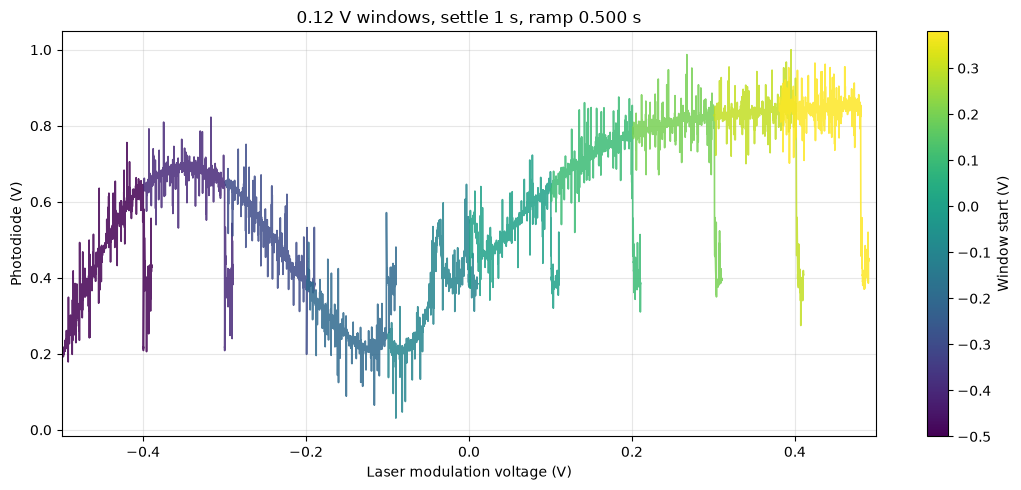

(<Figure size 1100x500 with 2 Axes>,
 <Axes: title={'center': '0.12 V windows, settle 1 s, ramp 0.500 s'}, xlabel='Laser modulation voltage (V)', ylabel='Photodiode (V)'>)

In [4]:
# ------------------------------------------------------------
# 3. 0.12 V windows, 0.1 V steps, 1 s settle
# ------------------------------------------------------------

WINDOW_V = 0.12
STEP_V = 0.10
RANGE_START_V = -0.5
RANGE_STOP_V = +0.5
SETTLE_S = 1.0
SCAN_TIME_S = 0.5  # not 0.15 s: survey-style 0 V tail + ~50 ms lag wraps a 0.15 s ramp

starts = np.arange(RANGE_START_V, RANGE_STOP_V - WINDOW_V + 1e-12, STEP_V)
if len(starts) == 0 or starts[-1] + WINDOW_V < RANGE_STOP_V - 1e-9:
    starts = np.append(starts, RANGE_STOP_V - WINDOW_V)
starts = np.unique(np.round(starts, 6))

traces = []
origins = []
silence_feedback(rp)
print(
    f"{len(starts)} windows,  {WINDOW_V:.3f} V wide,  "
    f"settle {SETTLE_S:.1f} s,  ramp {SCAN_TIME_S:.3f} s"
)
for v0 in starts:
    v0 = float(v0)
    v1 = float(v0 + WINDOW_V)
    print()
    print(f"Window {v0:+.3f} -> {v1:+.3f} V")
    x, pd, _, _ = drive.quick_scan(
        start_v=v0,
        stop_v=v1,
        scan_time=SCAN_TIME_S,
        pause_s=SETTLE_S,
    )
    traces.append((x, pd))
    origins.append(v0)

overlay_pd(
    traces,
    origins,
    title=f"{WINDOW_V:.2f} V windows, settle {SETTLE_S:.0f} s, ramp {SCAN_TIME_S:.3f} s",
    xlim=(RANGE_START_V, RANGE_STOP_V),
    color_label="Window start (V)",
)


## 4 — Same windows, 10 s sit at each start


10 windows,  0.120 V wide,  settle 10.0 s,  ramp 0.500 s

Window -0.500 -> -0.380 V

------------------------------------------------------------
SURVEY SCAN (jump / ramp / release to 0 V)
------------------------------------------------------------
Holding -0.5000 V
Scan:      -0.500000 -> -0.380000 V
Scan time: 0.500 s
ASG period: 8.590 s   scope window 1.074 s  (decimation 8192)
Pause:     10.000 s
Holding +0.0000 V
Scan samples: 6943  (raw window 7019)
Kept voltage: -0.498799 -> -0.389533 V  (requested -0.500000 -> -0.380000 V)
Now holding:  +0.000000 V

Window -0.400 -> -0.280 V

------------------------------------------------------------
SURVEY SCAN (jump / ramp / release to 0 V)
------------------------------------------------------------
Holding -0.4000 V
Scan:      -0.400000 -> -0.280000 V
Scan time: 0.500 s
ASG period: 8.590 s   scope window 1.074 s  (decimation 8192)
Pause:     10.000 s
Holding +0.0000 V
Scan samples: 6943  (raw window 7019)
Kept voltage: -0.398791 -> -0.28

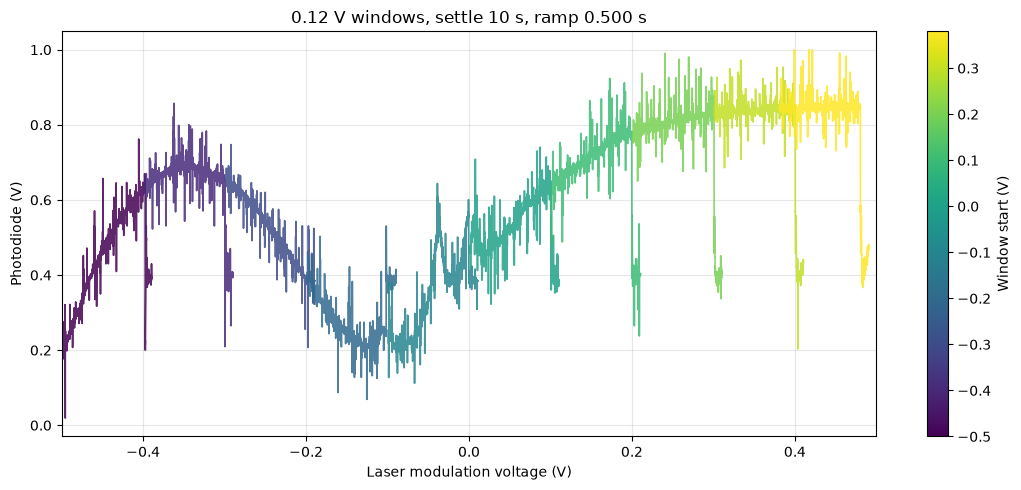

(<Figure size 1100x500 with 2 Axes>,
 <Axes: title={'center': '0.12 V windows, settle 10 s, ramp 0.500 s'}, xlabel='Laser modulation voltage (V)', ylabel='Photodiode (V)'>)

In [5]:
# ------------------------------------------------------------
# 4. 0.12 V windows, 0.1 V steps, 10 s settle
# ------------------------------------------------------------

WINDOW_V = 0.12
STEP_V = 0.10
RANGE_START_V = -0.5
RANGE_STOP_V = +0.5
SETTLE_S = 10.0
SCAN_TIME_S = 0.5  # not 0.15 s: survey-style 0 V tail + ~50 ms lag wraps a 0.15 s ramp

starts = np.arange(RANGE_START_V, RANGE_STOP_V - WINDOW_V + 1e-12, STEP_V)
if len(starts) == 0 or starts[-1] + WINDOW_V < RANGE_STOP_V - 1e-9:
    starts = np.append(starts, RANGE_STOP_V - WINDOW_V)
starts = np.unique(np.round(starts, 6))

traces = []
origins = []
silence_feedback(rp)
print(
    f"{len(starts)} windows,  {WINDOW_V:.3f} V wide,  "
    f"settle {SETTLE_S:.1f} s,  ramp {SCAN_TIME_S:.3f} s"
)
for v0 in starts:
    v0 = float(v0)
    v1 = float(v0 + WINDOW_V)
    print()
    print(f"Window {v0:+.3f} -> {v1:+.3f} V")
    x, pd, _, _ = drive.quick_scan(
        start_v=v0,
        stop_v=v1,
        scan_time=SCAN_TIME_S,
        pause_s=SETTLE_S,
    )
    traces.append((x, pd))
    origins.append(v0)

overlay_pd(
    traces,
    origins,
    title=f"{WINDOW_V:.2f} V windows, settle {SETTLE_S:.0f} s, ramp {SCAN_TIME_S:.3f} s",
    xlim=(RANGE_START_V, RANGE_STOP_V),
    color_label="Window start (V)",
)


## 5 — Same 0.12 V windows, 1 s sit, **8 s ramp**

Same geometry as cell 3. Sweep is ~8 s (longest PyRPL scope record). 0.12 V in 8 s is 15 mV/s, vs 240 mV/s at 0.5 s.


10 windows,  0.120 V wide,  settle 1.0 s,  ramp 8.000 s  (15.00 mV/s)

Window -0.500 -> -0.380 V

------------------------------------------------------------
SURVEY SCAN (jump / ramp / release to 0 V)
------------------------------------------------------------
Holding -0.5000 V
Scan:      -0.500000 -> -0.380000 V
Scan time: 8.000 s
ASG period: 8.590 s   scope window 8.590 s  (decimation 65536)
Pause:     1.000 s
Holding +0.0000 V
Scan samples: 13886  (raw window 14038)
Kept voltage: -0.498797 -> -0.389602 V  (requested -0.500000 -> -0.380000 V)
Now holding:  +0.000000 V

Window -0.400 -> -0.280 V

------------------------------------------------------------
SURVEY SCAN (jump / ramp / release to 0 V)
------------------------------------------------------------
Holding -0.4000 V
Scan:      -0.400000 -> -0.280000 V
Scan time: 8.000 s
ASG period: 8.590 s   scope window 8.590 s  (decimation 65536)
Pause:     1.000 s
Holding +0.0000 V
Scan samples: 13886  (raw window 14038)
Kept voltage: -

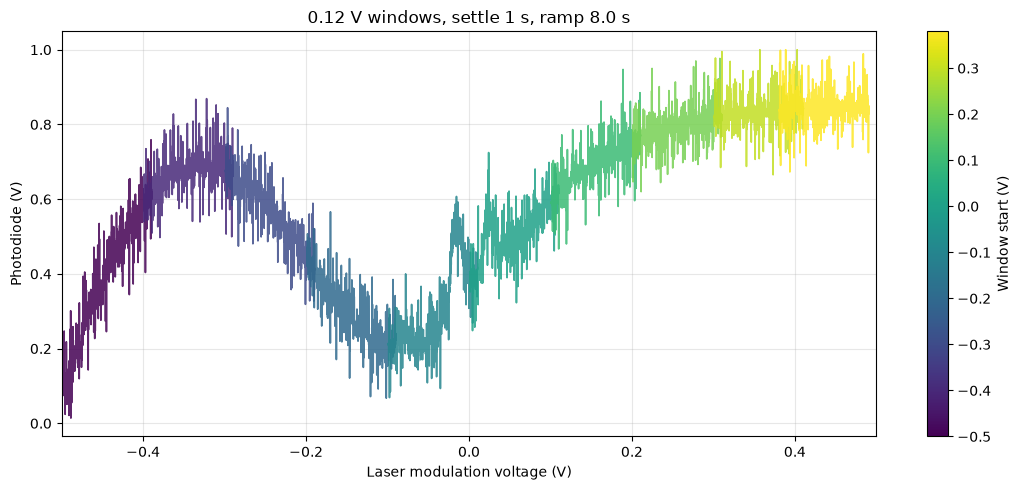

(<Figure size 1100x500 with 2 Axes>,
 <Axes: title={'center': '0.12 V windows, settle 1 s, ramp 8.0 s'}, xlabel='Laser modulation voltage (V)', ylabel='Photodiode (V)'>)

In [6]:
# ------------------------------------------------------------
# 5. 0.12 V windows, 1 s settle, 8 s ramp
# ------------------------------------------------------------

WINDOW_V = 0.12
STEP_V = 0.10
RANGE_START_V = -0.5
RANGE_STOP_V = +0.5
SETTLE_S = 1.0
SCAN_TIME_S = 8.0  # longest legal PyRPL scope window is ~8.59 s

starts = np.arange(RANGE_START_V, RANGE_STOP_V - WINDOW_V + 1e-12, STEP_V)
if len(starts) == 0 or starts[-1] + WINDOW_V < RANGE_STOP_V - 1e-9:
    starts = np.append(starts, RANGE_STOP_V - WINDOW_V)
starts = np.unique(np.round(starts, 6))

traces = []
origins = []
silence_feedback(rp)
print(
    f"{len(starts)} windows,  {WINDOW_V:.3f} V wide,  "
    f"settle {SETTLE_S:.1f} s,  ramp {SCAN_TIME_S:.3f} s  "
    f"({WINDOW_V / SCAN_TIME_S * 1e3:.2f} mV/s)"
)
for v0 in starts:
    v0 = float(v0)
    v1 = float(v0 + WINDOW_V)
    print()
    print(f"Window {v0:+.3f} -> {v1:+.3f} V")
    x, pd, _, _ = drive.quick_scan(
        start_v=v0,
        stop_v=v1,
        scan_time=SCAN_TIME_S,
        pause_s=SETTLE_S,
    )
    traces.append((x, pd))
    origins.append(v0)

overlay_pd(
    traces,
    origins,
    title=f"{WINDOW_V:.2f} V windows, settle {SETTLE_S:.0f} s, ramp {SCAN_TIME_S:.1f} s",
    xlim=(RANGE_START_V, RANGE_STOP_V),
    color_label="Window start (V)",
)


## 6 — Same 0.12 V windows, 10 s sit, **8 s ramp**


10 windows,  0.120 V wide,  settle 10.0 s,  ramp 8.000 s  (15.00 mV/s)

Window -0.500 -> -0.380 V

------------------------------------------------------------
SURVEY SCAN (jump / ramp / release to 0 V)
------------------------------------------------------------
Holding -0.5000 V
Scan:      -0.500000 -> -0.380000 V
Scan time: 8.000 s
ASG period: 8.590 s   scope window 8.590 s  (decimation 65536)
Pause:     10.000 s
Holding +0.0000 V
Scan samples: 13886  (raw window 14038)
Kept voltage: -0.498800 -> -0.389605 V  (requested -0.500000 -> -0.380000 V)
Now holding:  +0.000000 V

Window -0.400 -> -0.280 V

------------------------------------------------------------
SURVEY SCAN (jump / ramp / release to 0 V)
------------------------------------------------------------
Holding -0.4000 V
Scan:      -0.400000 -> -0.280000 V
Scan time: 8.000 s
ASG period: 8.590 s   scope window 8.590 s  (decimation 65536)
Pause:     10.000 s
Holding +0.0000 V
Scan samples: 13886  (raw window 14039)
Kept voltage

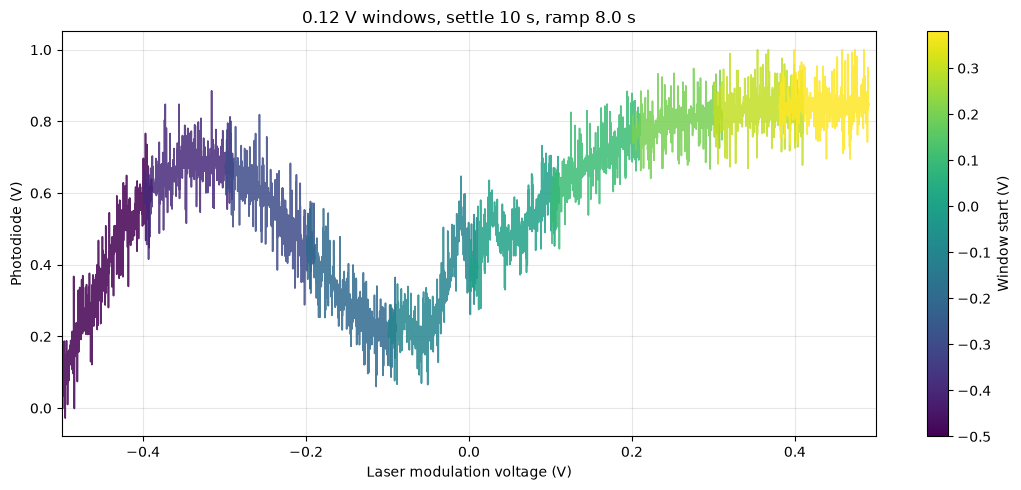

(<Figure size 1100x500 with 2 Axes>,
 <Axes: title={'center': '0.12 V windows, settle 10 s, ramp 8.0 s'}, xlabel='Laser modulation voltage (V)', ylabel='Photodiode (V)'>)

In [7]:
# ------------------------------------------------------------
# 6. 0.12 V windows, 10 s settle, 8 s ramp
# ------------------------------------------------------------

WINDOW_V = 0.12
STEP_V = 0.10
RANGE_START_V = -0.5
RANGE_STOP_V = +0.5
SETTLE_S = 10.0
SCAN_TIME_S = 8.0  # longest legal PyRPL scope window is ~8.59 s

starts = np.arange(RANGE_START_V, RANGE_STOP_V - WINDOW_V + 1e-12, STEP_V)
if len(starts) == 0 or starts[-1] + WINDOW_V < RANGE_STOP_V - 1e-9:
    starts = np.append(starts, RANGE_STOP_V - WINDOW_V)
starts = np.unique(np.round(starts, 6))

traces = []
origins = []
silence_feedback(rp)
print(
    f"{len(starts)} windows,  {WINDOW_V:.3f} V wide,  "
    f"settle {SETTLE_S:.1f} s,  ramp {SCAN_TIME_S:.3f} s  "
    f"({WINDOW_V / SCAN_TIME_S * 1e3:.2f} mV/s)"
)
for v0 in starts:
    v0 = float(v0)
    v1 = float(v0 + WINDOW_V)
    print()
    print(f"Window {v0:+.3f} -> {v1:+.3f} V")
    x, pd, _, _ = drive.quick_scan(
        start_v=v0,
        stop_v=v1,
        scan_time=SCAN_TIME_S,
        pause_s=SETTLE_S,
    )
    traces.append((x, pd))
    origins.append(v0)

overlay_pd(
    traces,
    origins,
    title=f"{WINDOW_V:.2f} V windows, settle {SETTLE_S:.0f} s, ramp {SCAN_TIME_S:.1f} s",
    xlim=(RANGE_START_V, RANGE_STOP_V),
    color_label="Window start (V)",
)


In [8]:
# ------------------------------------------------------------
# Shutdown
# ------------------------------------------------------------

drive.shutdown()


Shutdown: disconnect PID/IQ from OUT1, then slew ASG to idle.
OUT1 after slew (ASG still connected): +0.0 mV  ptp 0.0 mV
OUT1 after ASG disconnect: +0.0 mV  ptp 0.0 mV
OUT1 routes:
  asg0.output_direct=off
  asg1.output_direct=off
  pid0.output_direct=off  p=0.0  i=0.0  ival=+0.0000
  pid1.output_direct=off  p=0.0  i=0.0  ival=+0.0000
  pid2.output_direct=off  p=0.0  i=0.0  ival=+0.0000
  iq0.output_direct=off  amp=0.0000
  iq1.output_direct=off  amp=0.0000
  iq2.output_direct=off  amp=0.0000
Shutdown done. ASG disconnected.
